<a href="https://colab.research.google.com/github/bangaru01/C_programing/blob/main/R3_TS2_alignement_Superimpose_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import os
import pandas as pd
import numpy as np
import shutil # Added for directory operations

from morfeus import Sterimol, BuriedVolume, read_xyz


# ============================================================
# INSTALL
# ============================================================

!pip install -q morfeus-ml pandas numpy openpyxl


# ============================================================
# GOOGLE DRIVE
# ============================================================

from google.colab import drive

# Unmount drive first to avoid "Mountpoint must not already contain files" error
if os.path.ismount('/content/drive'):
    print("Drive is mounted, attempting to unmount.")
    try:
        drive.flush_and_unmount()
        print("Drive unmounted successfully.")
    except Exception as e:
        print(f"Error unmounting drive: {e}")
elif os.path.exists('/content/drive') and os.listdir('/content/drive'):
    print("Mountpoint /content/drive exists and contains files not managed by drive.mount(). Clearing contents...")
    try:
        for item in os.listdir('/content/drive'):
            item_path = os.path.join('/content/drive', item)
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        print("Contents of /content/drive cleared.")
    except Exception as e:
        print(f"Error clearing /content/drive: {e}. Attempting mount anyway.")
else:
    print("Mountpoint /content/drive is either empty or does not exist. Proceeding with mount.")

drive.mount('/content/drive', force_remount=True)


# ============================================================
# IMPORTS
# ============================================================




# ============================================================
# PATH
# ============================================================

xyz_folder = "/content/drive/MyDrive/xyz_files"


# ============================================================
# YOUR FIXED XYZ NUMBERING
#
# DDQ       = 1–15
# Substrate = 16–rest
# C2        = 18
# H on C2   = 43
# R3 first  = 44
# R3        = 44–last atom
# ============================================================

C2_ATOM = 18
R3_START_ATOM = 44


# ============================================================
# R3 NAMES
#
# If filename is not listed here, filename itself is used.
# ============================================================

R3_names = {

    "RR_Me.xyz": "Me",
    "RR_Et.xyz": "Et",
    "RR_iPr.xyz": "i-Pr",
    "RR_nBu.xyz": "n-Bu",
    "RR_tBu.xyz": "t-Bu",
    "RR_Cy.xyz": "Cy",
    "RR_CH2CO2Me.xyz": "CH2CO2Me",
    "RR_CMe2CO2Me.xyz": "CMe2CO2Me",
    "RR_allyl.xyz": "CH2CH=CH2",
    "RR_CMe2CHCH2.xyz": "CMe2CH=CH2",
    "RR_CH2_dioxolane.xyz": "CH2-1,3-dioxolane",
    "RR_CH2Ph.xyz": "CH2Ph",
    "RR_CH2CN.xyz": "CH2CN",
    "RR_Ph.xyz": "Phenyl",
    "RR_vinyl.xyz": "CH=CH2",
    "RR_alkyne.xyz": "C#CH"
}


# ============================================================
# STORAGE
# ============================================================

results = []


# ============================================================
# GET ALL XYZ FILES
# ============================================================

xyz_files = sorted([

    f for f in os.listdir(xyz_folder)

    if f.lower().endswith(".xyz")

])


print("Number of XYZ files:", len(xyz_files))


# ============================================================
# PROCESS EVERY XYZ
# ============================================================

for file in xyz_files:

    print("\n====================================================")
    print("Processing:", file)
    print("====================================================")

    path = os.path.join(xyz_folder, file)

    try:

        # ----------------------------------------------------
        # READ XYZ
        # ----------------------------------------------------

        elements, coordinates = read_xyz(path)

        n_atoms = len(elements)


        # ----------------------------------------------------
        # CHECK NUMBERING
        # ----------------------------------------------------

        if n_atoms < R3_START_ATOM:

            raise ValueError(
                f"Only {n_atoms} atoms found; "
                f"R3 should start at atom {R3_START_ATOM}."
            )


        # ----------------------------------------------------
        # DEFINE R3
        #
        # Because your numbering is standardized:
        #
        # R3 = 44 through the last atom
        # ----------------------------------------------------

        R3_atoms = list(
            range(R3_START_ATOM, n_atoms + 1)
        )


        print(
            "R3 atoms:",
            R3_atoms
        )


        # ----------------------------------------------------
        # CHECK C18-C44 DISTANCE
        # ----------------------------------------------------

        c18 = coordinates[C2_ATOM - 1]

        c44 = coordinates[R3_START_ATOM - 1]

        c18_c44_distance = np.linalg.norm(
            c18 - c44
        )


        print(
            f"C18-C44 distance = "
            f"{c18_c44_distance:.3f} Å"
        )


        # ====================================================
        # STERIMOL
        #
        # YOUR DEFINED STERIC AXIS:
        #
        # C18 --------------------> C44
        # C2                         first R3 carbon
        #
        # IMPORTANT:
        # Morfeus indices are 1-based.
        # ====================================================

        keep_atoms = set(
            [C2_ATOM] + R3_atoms
        )


        # Exclude DDQ + remaining substrate atoms
        excluded_atoms = [

            i

            for i in range(1, n_atoms + 1)

            if i not in keep_atoms

        ]


        sterimol = Sterimol(

            elements,
            coordinates,

            dummy_index=C2_ATOM,

            attached_index=R3_START_ATOM,

            excluded_atoms=excluded_atoms,

            radii_type="crc",

            n_rot_vectors=3600

        )


        # ----------------------------------------------------
        # STERIMOL VALUES
        # ----------------------------------------------------

        B1 = sterimol.B_1_value

        B5 = sterimol.B_5_value

        L = sterimol.L_value


        print(
            f"Sterimol B1 = {B1:.3f} Å"
        )

        print(
            f"Sterimol B5 = {B5:.3f} Å"
        )

        print(
            f"Sterimol L  = {L:.3f} Å"
        )


        # ====================================================
        # CUSTOM R3 %VBUR
        #
        # Center = C18
        #
        # Only R3 atoms are allowed to contribute.
        #
        # C18 itself is the center and is automatically
        # excluded from the buried-volume contribution.
        # ====================================================

        vbur_excluded_atoms = [

            i

            for i in range(1, n_atoms + 1)

            if i not in R3_atoms

        ]


        buried = BuriedVolume(

            elements,

            coordinates,

            metal_index=C2_ATOM,

            excluded_atoms=vbur_excluded_atoms,

            radius=3.5,

            include_hs=False,

            radii_type="bondi"

        )


        # ----------------------------------------------------
        # %VBUR
        # ----------------------------------------------------

        # Changed from percent_buried_volume due to DeprecationWarning
        percent_vbur = buried.fraction_buried_volume * 100


        print(
            f"%Vbur = {percent_vbur:.3f} %"
        )


        # ====================================================
        # R3 NAME
        # ====================================================

        R3 = R3_names.get(

            file,

            os.path.splitext(file)[0]

        )


        # ====================================================
        # SAVE
        # ====================================================

        results.append({

            "File": file,

            "R3": R3,

            "C2 atom": C2_ATOM,

            "R3 first atom": R3_START_ATOM,

            "R3 atoms":
                f"{R3_START_ATOM}-{n_atoms}",

            "C18-C44 distance (Å)":
                c18_c44_distance,

            "B1 (Å)": B1,

            "B5 (Å)": B5,

            "L (Å)": L,

            "%Vbur": percent_vbur

        })


        print(
            "SUCCESS"
        )


    except Exception as e:

        print(
            f"ERROR in {file}: {e}"
        )


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(results)


# ============================================================
# SAVE CSV
# ============================================================

csv_file = os.path.join(

    xyz_folder,

    "R3_Sterimol_Vbur_results_new.csv"

)

df.to_csv(

    csv_file,

    index=False

)


# ============================================================
# SAVE EXCEL
# ============================================================

xlsx_file = os.path.join(

    xyz_folder,

    "R3_Sterimol_Vbur_results_new.xlsx"

)

df.to_excel(

    xlsx_file,

    index=False

)


# ============================================================
# DISPLAY
# ============================================================

print("\n")
print("====================================================")
print("CALCULATION COMPLETED")
print("====================================================")

print(
    "CSV   :", csv_file
)

print(
    "Excel :", xlsx_file
)

print("\nRESULTS:")

display(df)

Drive is mounted, attempting to unmount.
Drive unmounted successfully.
Mounted at /content/drive
Number of XYZ files: 34

Processing: RR_CH2-Ph.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]
C18-C44 distance = 1.529 Å
Sterimol B1 = 1.700 Å
Sterimol B5 = 5.853 Å
Sterimol L  = 6.870 Å
%Vbur = 27.159 %
SUCCESS

Processing: RR_CH2-dioxane.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]
C18-C44 distance = 1.529 Å
Sterimol B1 = 1.700 Å
Sterimol B5 = 5.246 Å
Sterimol L  = 6.142 Å
%Vbur = 26.385 %
SUCCESS

Processing: RR_CH2CN.xyz
R3 atoms: [44, 45, 46, 47, 48]
C18-C44 distance = 1.540 Å
Sterimol B1 = 1.700 Å
Sterimol B5 = 3.992 Å
Sterimol L  = 4.439 Å
%Vbur = 23.967 %
SUCCESS

Processing: RR_CH2CO2Me.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
C18-C44 distance = 1.530 Å
Sterimol B1 = 1.700 Å
Sterimol B5 = 4.957 Å
Sterimol L  = 5.778 Å
%Vbur = 26.479 %
SUCCESS

Processing: RR_CMe2CO2Me.xyz
R3 atoms: [44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 

,File,R3,C2 atom,R3 first atom,R3 atoms,C18-C44 distance (Å),B1 (Å),B5 (Å),L (Å),%Vbur
0,RR_CH2-Ph.xyz,RR_CH2-Ph,18,44,44-57,1.529416,1.700000,5.852931,6.869516,27.158847
1,RR_CH2-dioxane.xyz,RR_CH2-dioxane,18,44,44-56,1.528873,1.700000,5.245980,6.141713,26.384877
2,RR_CH2CN.xyz,CH2CN,18,44,44-48,1.539665,1.700000,3.992223,4.438541,23.967457
3,RR_CH2CO2Me.xyz,CH2CO2Me,18,44,44-53,1.529564,1.700000,4.957261,5.777883,26.479221
4,RR_CMe2CO2Me.xyz,CMe2CO2Me,18,44,44-59,1.552641,2.841477,5.068311,5.512985,37.009062
5,RR_Cy.xyz,Cy,18,44,44-60,1.539015,2.006980,3.676088,6.749453,29.255381
6,RR_Et.xyz,Et,18,44,44-50,1.529597,1.700000,3.255715,4.676969,23.887090
7,RR_Me-Propane.xyz,RR_Me-Propane,18,44,44-56,1.537140,1.700000,4.502030,5.803826,26.875233
8,RR_Me.xyz,Me,18,44,44-47,1.525097,1.700000,2.129183,3.625097,18.369712
9,RR_Ph.xyz,Phenyl,18,44,44-54,1.519774,1.700000,3.272252,6.899519,27.759271


                R3  C18_C44_dist        B1        B5         L  pct_Vbur  \
0           CH2-Ph      1.529416  1.700000  5.852931  6.869516  0.271588   
1      CH2-dioxane      1.528873  1.700000  5.245980  6.141713  0.263849   
2            CH2CN      1.539665  1.700000  3.992223  4.438541  0.239675   
3         CH2CO2Me      1.529564  1.700000  4.957261  5.777883  0.264792   
4        CMe2CO2Me      1.552641  2.841477  5.068311  5.512985  0.370091   
5               Cy      1.539015  2.006980  3.676088  6.749453  0.292554   
6               Et      1.529597  1.700000  3.255715  4.676969  0.238871   
7       Me-Propane      1.537140  1.700000  4.502030  5.803826  0.268752   
8               Me      1.525097  1.700000  2.129183  3.625097  0.183697   
9               Ph      1.519774  1.700000  3.272252  6.899519  0.277593   
10          alkene      1.509653  1.700000  3.180606  4.831029  0.228272   
11          alkyne      1.474722  1.700000  1.712028  5.247814  0.208774   
12          

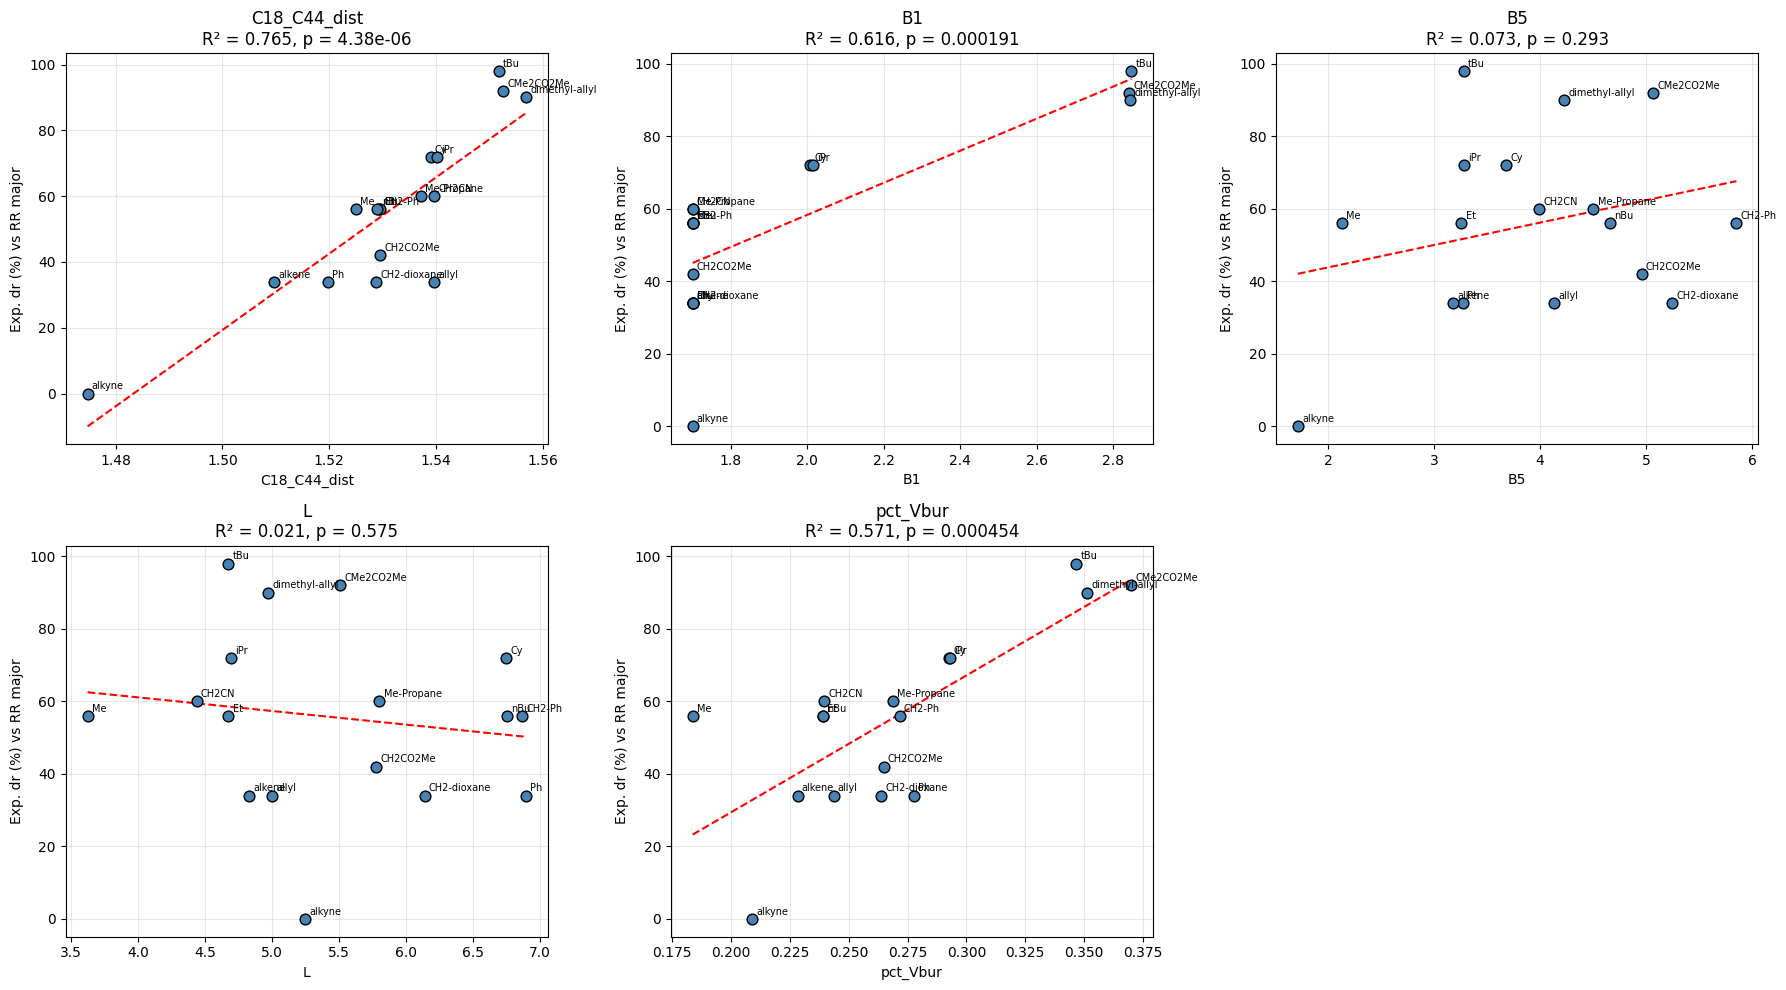


✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/correlation_descriptors_vs_dr.png


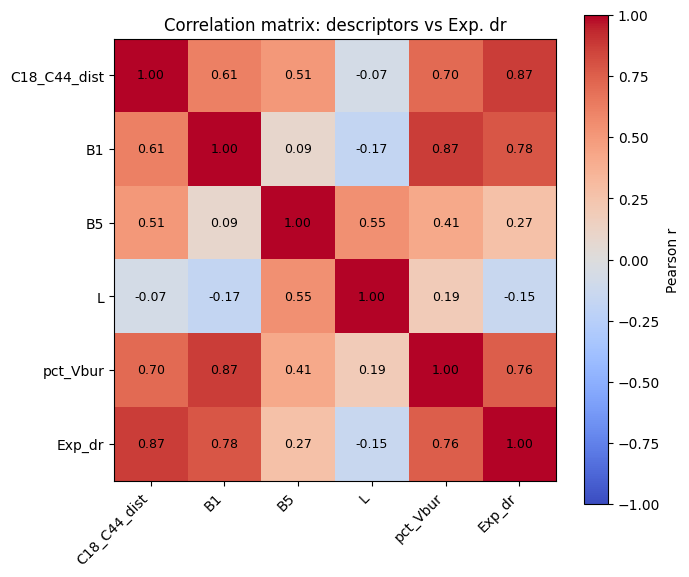

✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/correlation_heatmap.png


In [11]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# ============================================================
# 1. DATA — transcribed from your table (RR series, with Exp selectivity)
# ============================================================
data = {
    "R3": ["CH2-Ph", "CH2-dioxane", "CH2CN", "CH2CO2Me", "CMe2CO2Me", "Cy", "Et",
           "Me-Propane", "Me", "Ph", "alkene", "alkyne", "allyl", "dimethyl-allyl",
           "iPr", "nBu", "tBu"],
    "C18_C44_dist": [1.529416144, 1.528873288, 1.539664539, 1.529563911, 1.552641331,
                      1.539014927, 1.529596644, 1.537140364, 1.525096563, 1.519774304,
                      1.509652986, 1.474721903, 1.539668337, 1.556932552, 1.540264311,
                      1.52905731, 1.551790347],
    "B1": [1.7, 1.7, 1.7, 1.7, 2.841477401, 2.006980481, 1.7, 1.7, 1.7, 1.7, 1.7, 1.7,
           1.7, 2.845495002, 2.01483892, 1.7, 2.84782909],
    "B5": [5.852931423, 5.245979701, 3.992222701, 4.957261478, 5.068311164, 3.676088041,
           3.255714689, 4.502029815, 2.129182645, 3.272252159, 3.180605577, 1.712027791,
           4.128135092, 4.225435636, 3.276498467, 4.661634076, 3.280251337],
    "L": [6.869515854, 6.14171285, 4.438541422, 5.777883105, 5.512984644, 6.749453254,
          4.676969375, 5.803826209, 3.625096563, 6.899519327, 4.831029456, 5.247814367,
          5.00005738, 4.974717983, 4.698652697, 6.757457655, 4.676915531],
    "pct_Vbur": [0.271588474, 0.26384877, 0.239674571, 0.26479221, 0.370090617, 0.292553811,
                 0.2388709, 0.268752329, 0.183697121, 0.277592713, 0.228271757, 0.208773994,
                 0.243599748, 0.351233461, 0.293142005, 0.238969903, 0.346679324],
    "Exp_dr": [56, 34, 60, 42, 92, 72, 56, 60, 56, 34, 34, 0, 34, 90, 72, 56, 98],
}

df = pd.DataFrame(data)
print(df)

# ============================================================
# 2. CORRELATION ANALYSIS — Pearson r, R², p-value for each descriptor
# ============================================================
descriptors = ["C18_C44_dist", "B1", "B5", "L", "pct_Vbur"]
results = []

for desc in descriptors:
    r, p = stats.pearsonr(df[desc], df["Exp_dr"])
    results.append({"Descriptor": desc, "Pearson r": r, "R2": r**2, "p-value": p})

corr_summary = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\nCorrelation with Exp. diastereoselectivity:")
print(corr_summary.to_string(index=False))

# ============================================================
# 3. INDIVIDUAL CORRELATION PLOTS (one per descriptor)
# ============================================================
out_dir = "/content/drive/MyDrive/xyz_files/superimposed_by_stereo"
os.makedirs(out_dir, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, desc in enumerate(descriptors):
    ax = axes[i]
    x = df[desc].values
    y = df["Exp_dr"].values

    # linear regression line
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    ax.scatter(x, y, color="steelblue", s=60, edgecolor="black", zorder=3)
    ax.plot(x_line, y_line, color="red", linestyle="--", linewidth=1.5, zorder=2)

    # label each point with R3 name
    for xi, yi, label in zip(x, y, df["R3"]):
        ax.annotate(label, (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel(desc)
    ax.set_ylabel("Exp. dr (%) vs RR major")
    ax.set_title(f"{desc}\nR² = {r**2:.3f}, p = {p:.3g}")
    ax.grid(alpha=0.3)

# remove unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plot_path = os.path.join(out_dir, "correlation_descriptors_vs_dr.png")
plt.savefig(plot_path, dpi=200)
plt.show()
print(f"\n✅ Saved: {plot_path}")

# ============================================================
# 4. CORRELATION HEATMAP (all descriptors + Exp_dr)
# ============================================================
corr_matrix = df[descriptors + ["Exp_dr"]].corr()

fig2, ax2 = plt.subplots(figsize=(7, 6))
im = ax2.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr_matrix)))
ax2.set_yticks(range(len(corr_matrix)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax2.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax2.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center",
                  color="black", fontsize=9)

fig2.colorbar(im, ax=ax2, label="Pearson r")
ax2.set_title("Correlation matrix: descriptors vs Exp. dr")
plt.tight_layout()

heatmap_path = os.path.join(out_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=200)
plt.show()
print(f"✅ Saved: {heatmap_path}")

In [12]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# ============================================================
# 1. LOAD DESCRIPTOR TABLE FROM EXCEL
# ============================================================
xyz_folder = "/content/drive/MyDrive/xyz_files"
excel_path = os.path.join(xyz_folder, "R3_Sterimol_Vbur_results_new.xlsx")

df = pd.read_excel(excel_path)
print(f"Loaded {len(df)} rows, columns: {df.columns.tolist()}\n")
df

Loaded 34 rows, columns: ['File', 'R3', 'C2 atom', 'R3 first atom', 'R3 atoms', 'C18-C44 distance (Å)', 'B1 (Å)', 'B5 (Å)', 'L (Å)', '%Vbur']



,File,R3,C2 atom,R3 first atom,R3 atoms,C18-C44 distance (Å),B1 (Å),B5 (Å),L (Å),%Vbur
0,RR_CH2-Ph.xyz,RR_CH2-Ph,18,44,44-57,1.529416,1.700000,5.852931,6.869516,27.158847
1,RR_CH2-dioxane.xyz,RR_CH2-dioxane,18,44,44-56,1.528873,1.700000,5.245980,6.141713,26.384877
2,RR_CH2CN.xyz,CH2CN,18,44,44-48,1.539665,1.700000,3.992223,4.438541,23.967457
3,RR_CH2CO2Me.xyz,CH2CO2Me,18,44,44-53,1.529564,1.700000,4.957261,5.777883,26.479221
4,RR_CMe2CO2Me.xyz,CMe2CO2Me,18,44,44-59,1.552641,2.841477,5.068311,5.512985,37.009062
5,RR_Cy.xyz,Cy,18,44,44-60,1.539015,2.006980,3.676088,6.749453,29.255381
6,RR_Et.xyz,Et,18,44,44-50,1.529597,1.700000,3.255715,4.676969,23.887090
7,RR_Me-Propane.xyz,RR_Me-Propane,18,44,44-56,1.537140,1.700000,4.502030,5.803826,26.875233
8,RR_Me.xyz,Me,18,44,44-47,1.525097,1.700000,2.129183,3.625097,18.369712
9,RR_Ph.xyz,Phenyl,18,44,44-54,1.519774,1.700000,3.272252,6.899519,27.759271


In [13]:
# ============================================================
# 2. ADD EXPERIMENTAL %DE COLUMN (manually provided, RR series only)
# ============================================================
exp_de = {
    "RR_CH2-Ph.xyz": 56,
    "RR_CH2-dioxane.xyz": 34,
    "RR_CH2CN.xyz": 60,
    "RR_CH2CO2Me.xyz": 42,
    "RR_CMe2CO2Me.xyz": 92,
    "RR_Cy.xyz": 72,
    "RR_Et.xyz": 56,
    "RR_Me-Propane.xyz": 60,
    "RR_Me.xyz": 56,
    "RR_Ph.xyz": 34,
    "RR_alkene.xyz": 34,
    "RR_alkyne.xyz": 0,
    "RR_allyl.xyz": 34,
    "RR_dimethyl-allyl.xyz": 90,
    "RR_iPr.xyz": 72,
    "RR_nBu.xyz": 56,
    "RR_tBu.xyz": 98,
}

df["Exp diastereo Selectivity (%) wrt RR (major)"] = df["File"].map(exp_de)

# Sanity check: any RR_ files that didn't get matched (spelling mismatch etc.)
missing = df[df["File"].astype(str).str.startswith("RR_") &
             df["Exp diastereo Selectivity (%) wrt RR (major)"].isna()]
if len(missing) > 0:
    print("⚠️ These RR files were NOT matched — check exact spelling in exp_de vs Excel 'File' column:")
    print(missing[["File"]])
else:
    print("✅ All RR files matched successfully.")

# ============================================================
# 3. DISPLAY FULL TABLE WITH NEW COLUMN
# ============================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(df)

# Save the merged table back to Excel for reference
merged_path = os.path.join(xyz_folder, "R3_Sterimol_Vbur_with_ExpDE.xlsx")
df.to_excel(merged_path, index=False)
print(f"\n✅ Saved merged table: {merged_path}")

✅ All RR files matched successfully.
                     File                 R3  C2 atom  R3 first atom R3 atoms  C18-C44 distance (Å)    B1 (Å)    B5 (Å)     L (Å)      %Vbur  Exp diastereo Selectivity (%) wrt RR (major)
0           RR_CH2-Ph.xyz          RR_CH2-Ph       18             44    44-57              1.529416  1.700000  5.852931  6.869516  27.158847                                          56.0
1      RR_CH2-dioxane.xyz     RR_CH2-dioxane       18             44    44-56              1.528873  1.700000  5.245980  6.141713  26.384877                                          34.0
2            RR_CH2CN.xyz              CH2CN       18             44    44-48              1.539665  1.700000  3.992223  4.438541  23.967457                                          60.0
3         RR_CH2CO2Me.xyz           CH2CO2Me       18             44    44-53              1.529564  1.700000  4.957261  5.777883  26.479221                                          42.0
4        RR_CMe2CO2Me.xyz   

17 structures with experimental %DE for correlation

Descriptors used: ['C18-C44 distance (Å)', 'B1 (Å)', 'B5 (Å)', 'L (Å)', '%Vbur']

Correlation with Exp. %DE:
          Descriptor  Pearson r       R2  p-value
C18-C44 distance (Å)   0.874606 0.764935 0.000004
              B1 (Å)   0.784713 0.615775 0.000191
               %Vbur   0.755425 0.570666 0.000454
              B5 (Å)   0.270795 0.073330 0.293132
               L (Å)  -0.146219 0.021380 0.575495


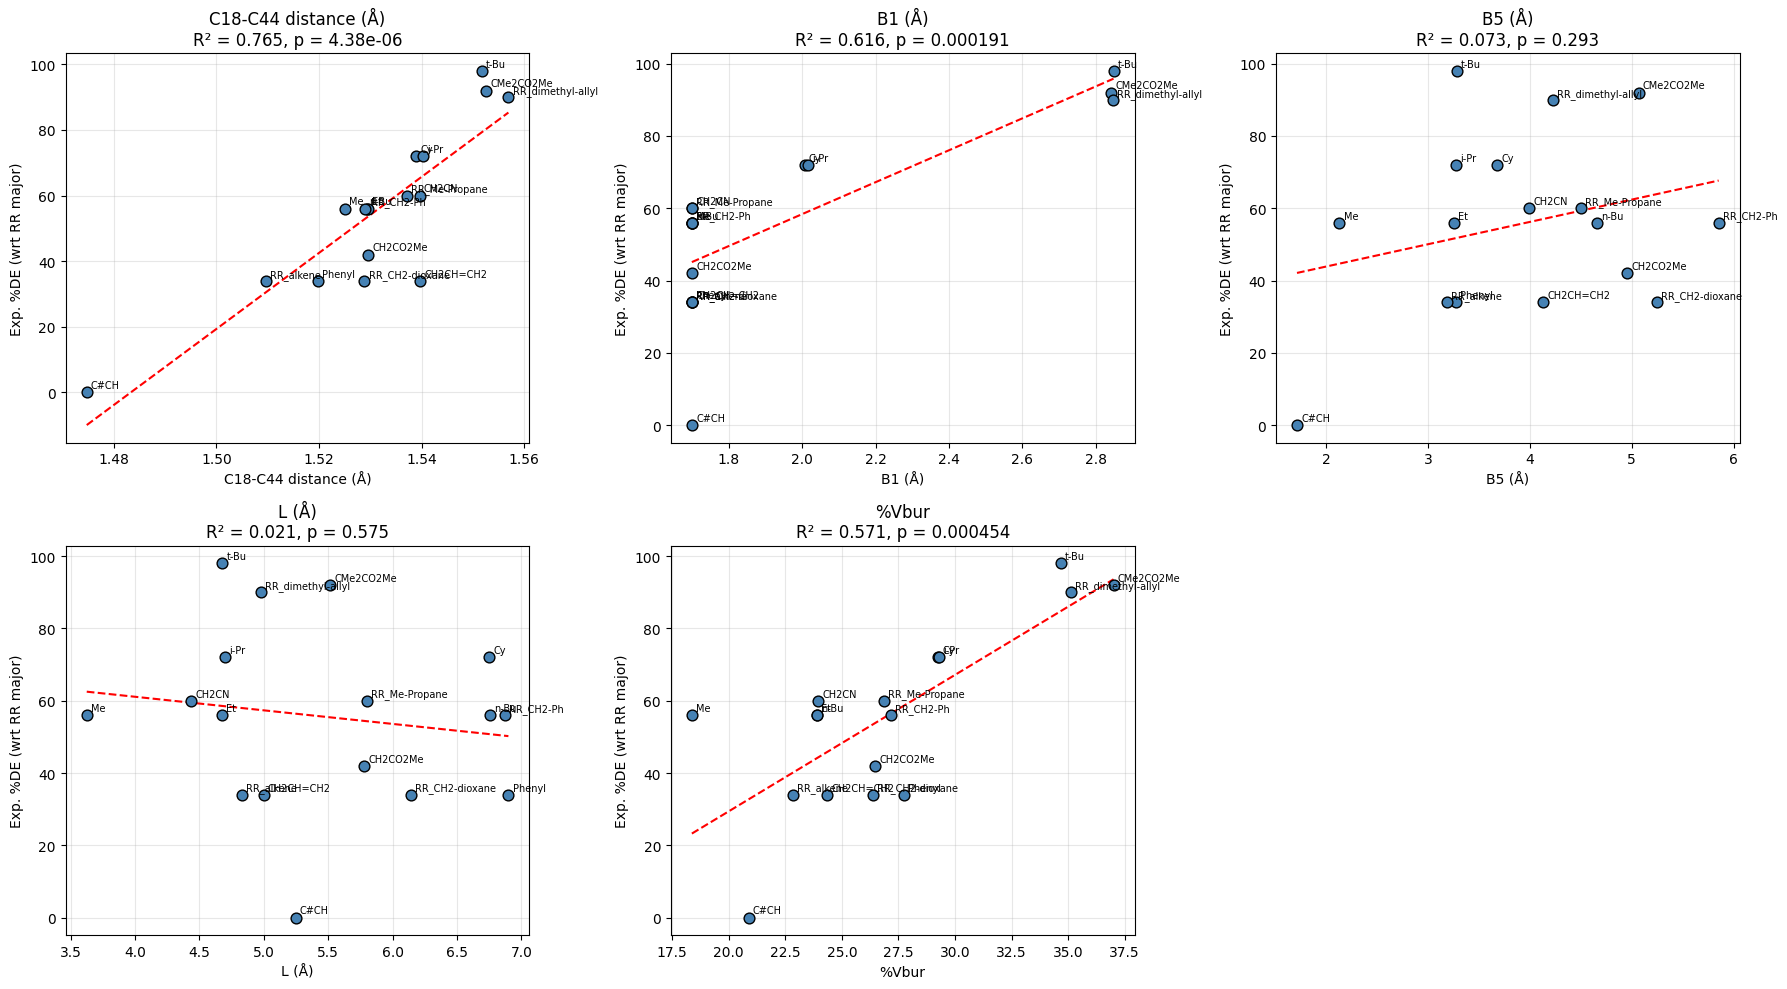


✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/correlation_descriptors_vs_DE.png


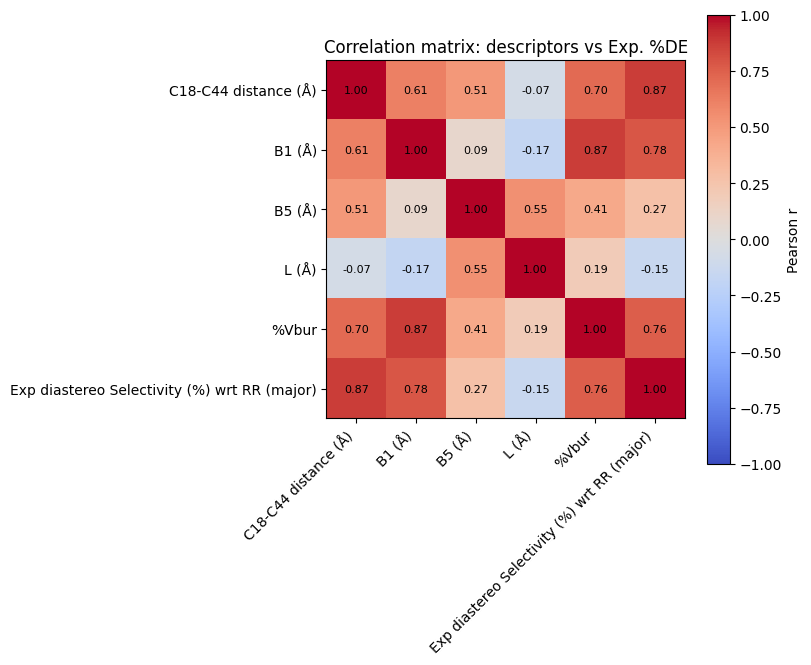

✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/correlation_heatmap_DE.png


In [14]:
# ============================================================
# 4. CORRELATION ANALYSIS (RR series only)
# ============================================================
de_col = "Exp diastereo Selectivity (%) wrt RR (major)"
df_rr = df[df[de_col].notna()].copy()
print(f"{len(df_rr)} structures with experimental %DE for correlation\n")

# Explicitly define descriptor columns (edit these to match your exact Excel headers if different)
descriptor_cols = [c for c in df.columns if c not in
                    ["File", "R3", "C2 atom", "R3 first atom", "R3 atoms", de_col]
                    and pd.api.types.is_numeric_dtype(df[c])]
print(f"Descriptors used: {descriptor_cols}")

results = []
for desc in descriptor_cols:
    x = df_rr[desc].values
    y = df_rr[de_col].values
    if np.std(x) == 0:
        continue
    r, p = stats.pearsonr(x, y)
    results.append({"Descriptor": desc, "Pearson r": r, "R2": r**2, "p-value": p})

corr_summary = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\nCorrelation with Exp. %DE:")
print(corr_summary.to_string(index=False))

# ============================================================
# 5. CORRELATION SCATTER PLOTS (one per descriptor)
# ============================================================
out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
os.makedirs(out_dir, exist_ok=True)

n = len(descriptor_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

label_col = "R3" if "R3" in df_rr.columns else "File"

for i, desc in enumerate(descriptor_cols):
    ax = axes[i]
    x = df_rr[desc].values
    y = df_rr[de_col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    ax.scatter(x, y, color="steelblue", s=60, edgecolor="black", zorder=3)
    ax.plot(x_line, y_line, color="red", linestyle="--", linewidth=1.5, zorder=2)

    for xi, yi, label in zip(x, y, df_rr[label_col]):
        ax.annotate(str(label), (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel(desc)
    ax.set_ylabel("Exp. %DE (wrt RR major)")
    ax.set_title(f"{desc}\nR² = {r**2:.3f}, p = {p:.3g}")
    ax.grid(alpha=0.3)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plot_path = os.path.join(out_dir, "correlation_descriptors_vs_DE.png")
plt.savefig(plot_path, dpi=200)
plt.show()
print(f"\n✅ Saved: {plot_path}")

# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================
corr_matrix = df_rr[descriptor_cols + [de_col]].corr()

fig2, ax2 = plt.subplots(figsize=(8, 7))
im = ax2.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr_matrix)))
ax2.set_yticks(range(len(corr_matrix)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax2.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax2.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig2.colorbar(im, ax=ax2, label="Pearson r")
ax2.set_title("Correlation matrix: descriptors vs Exp. %DE")
plt.tight_layout()

heatmap_path = os.path.join(out_dir, "correlation_heatmap_DE.png")
plt.savefig(heatmap_path, dpi=200)
plt.show()
print(f"✅ Saved: {heatmap_path}")

Ring atom identities and pairwise bonded distances (should all be ~1.4-1.5 Å):
  Sequence: [(17, 'O'), (18, 'C'), (19, 'C'), (20, 'C'), (21, 'C'), (22, 'C')]
  17(O) - 18(C): 1.399 Å
  18(C) - 19(C): 1.566 Å
  19(C) - 20(C): 1.481 Å
  20(C) - 21(C): 1.355 Å
  21(C) - 22(C): 1.427 Å
  22(C) - 17(O): 2.304 Å

=== RR ring puckering ===
                 File    Q (Å)  theta (deg)  phi (deg)       Conformer
        RR_CH2-Ph.xyz 0.750305    84.957809 110.395228 boat/twist-boat
   RR_CH2-dioxane.xyz 0.756486    82.323499 106.105305 boat/twist-boat
         RR_CH2CN.xyz 0.742216    83.502665 108.193968 boat/twist-boat
      RR_CH2CO2Me.xyz 0.763073    84.549046 109.792462 boat/twist-boat
     RR_CMe2CO2Me.xyz 0.770719    84.833495 110.505160 boat/twist-boat
            RR_Cy.xyz 0.760237    81.385897 104.838408 boat/twist-boat
            RR_Et.xyz 0.754595    81.933286 105.584384 boat/twist-boat
    RR_Me-Propane.xyz 0.747669    83.865742 108.284491 boat/twist-boat
            RR_Me.xyz 0.75

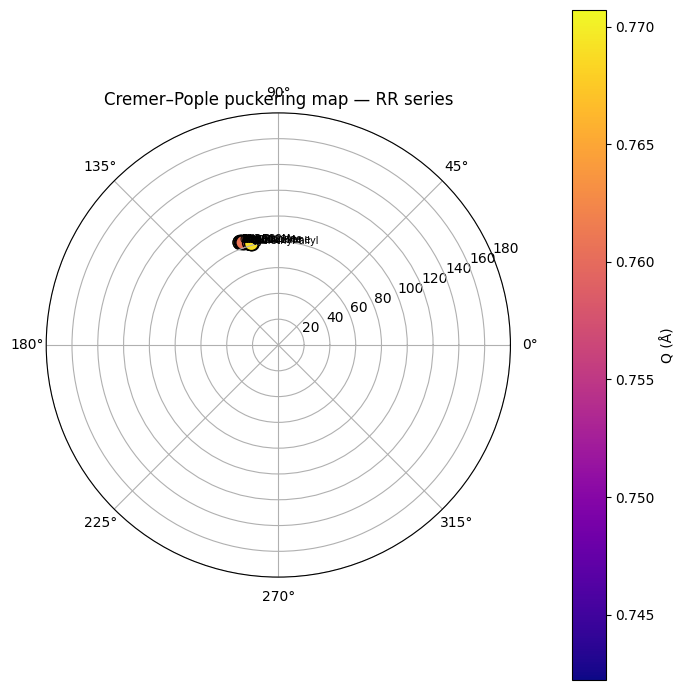

In [15]:
# ============================================================
# 1. CONFIG — CORRECTED PYRAN RING ATOMS (1-indexed)
# ============================================================
PYRAN_RING_1INDEXED = [17, 18, 19, 20, 21, 22]   # O17-C18-C19-C20-C21-C22-back to O17
ring_idx = [i - 1 for i in PYRAN_RING_1INDEXED]

xyz_folder = "/content/drive/MyDrive/xyz_files"

# ============================================================
# 2. XYZ READER (reuse from before)
# ============================================================
def read_xyz(path):
    with open(path) as f:
        lines = f.readlines()
    n_atoms = int(lines[0].strip())
    symbols, coords = [], []
    for line in lines[2:2 + n_atoms]:
        parts = line.split()
        symbols.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    return symbols, np.array(coords)

# ============================================================
# 3. SANITY CHECK — confirm these 6 atoms are really O-C-C-C-C-C bonded in sequence
# ============================================================
test_file = os.path.join(xyz_folder, "RR_Me.xyz")
symbols, coords = read_xyz(test_file)

print("Ring atom identities and pairwise bonded distances (should all be ~1.4-1.5 Å):")
ring_symbols = [symbols[i] for i in ring_idx]
print(f"  Sequence: {list(zip(PYRAN_RING_1INDEXED, ring_symbols))}")

ring_coords = coords[ring_idx]
for k in range(6):
    a, b = ring_coords[k], ring_coords[(k + 1) % 6]
    d = np.linalg.norm(a - b)
    print(f"  {PYRAN_RING_1INDEXED[k]}({ring_symbols[k]}) - "
          f"{PYRAN_RING_1INDEXED[(k+1)%6]}({ring_symbols[(k+1)%6]}): {d:.3f} Å")

# ============================================================
# 4. CREMER-POPLE RING PUCKERING (6-membered ring)
# ============================================================
def cremer_pople_6ring(coords):
    N = 6
    R = coords - coords.mean(axis=0)
    R1 = np.zeros(3)
    R2 = np.zeros(3)
    for j in range(N):
        R1 += R[j] * np.sin(2 * np.pi * j / N)
        R2 += R[j] * np.cos(2 * np.pi * j / N)
    n = np.cross(R1, R2)
    n /= np.linalg.norm(n)
    z = R @ n

    q2_cos = np.sqrt(2 / N) * sum(z[j] * np.cos(2 * np.pi * 2 * j / N) for j in range(N))
    q2_sin = -np.sqrt(2 / N) * sum(z[j] * np.sin(2 * np.pi * 2 * j / N) for j in range(N))
    q2 = np.sqrt(q2_cos**2 + q2_sin**2)
    phi2 = np.degrees(np.arctan2(q2_sin, q2_cos)) % 360

    q3 = np.sqrt(1 / N) * sum(z[j] * (-1) ** j for j in range(N))

    Q = np.sqrt(q2**2 + q3**2)
    theta = np.degrees(np.arctan2(q2, q3)) if Q > 1e-8 else 0.0
    theta = theta % 180

    if theta < 25 or theta > 155:
        conformer = "chair (4H5/5H4-like)"
    elif 55 < theta < 125:
        conformer = "boat/twist-boat"
    else:
        conformer = "half-chair/envelope"

    return Q, theta, phi2, conformer

# ============================================================
# 5. RUN ON ALL RR AND RS FILES
# ============================================================
def analyze_group(prefix):
    files = sorted(glob.glob(os.path.join(xyz_folder, f"{prefix}_*.xyz")))
    rows = []
    for f in files:
        symbols, coords = read_xyz(f)
        if max(ring_idx) >= len(coords):
            print(f"⚠️ {os.path.basename(f)}: not enough atoms — skipping")
            continue
        ring_coords = coords[ring_idx]
        Q, theta, phi, conf = cremer_pople_6ring(ring_coords)
        rows.append({"File": os.path.basename(f), "Q (Å)": Q, "theta (deg)": theta,
                      "phi (deg)": phi, "Conformer": conf})
    return pd.DataFrame(rows)

df_rr_pucker = analyze_group("RR")
df_rs_pucker = analyze_group("RS")

print("\n=== RR ring puckering ===")
print(df_rr_pucker.to_string(index=False))
print("\n=== RS ring puckering ===")
print(df_rs_pucker.to_string(index=False))

out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
os.makedirs(out_dir, exist_ok=True)
df_rr_pucker.to_csv(os.path.join(out_dir, "RR_ring_pucker.csv"), index=False)
df_rs_pucker.to_csv(os.path.join(out_dir, "RS_ring_pucker.csv"), index=False)

# ============================================================
# 6. PUCKERING MAP PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
theta_rad = np.radians(df_rr_pucker["phi (deg)"])
r = df_rr_pucker["theta (deg)"]
sc = ax.scatter(theta_rad, r, c=df_rr_pucker["Q (Å)"], cmap="plasma", s=100, edgecolor="black")
for _, row in df_rr_pucker.iterrows():
    ax.annotate(row["File"].replace("RR_", "").replace(".xyz", ""),
                (np.radians(row["phi (deg)"]), row["theta (deg)"]), fontsize=7)
ax.set_title("Cremer–Pople puckering map — RR series")
ax.set_ylim(0, 180)
fig.colorbar(sc, label="Q (Å)", pad=0.1)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "RR_pucker_map.png"), dpi=200)
plt.show()

In [16]:
# ============================================================
# EXTRACT FORMING C-O BOND DISTANCE (O17...C22) FOR ALL STRUCTURES
# ============================================================
def get_distance(coords, i_1indexed, j_1indexed):
    return np.linalg.norm(coords[i_1indexed - 1] - coords[j_1indexed - 1])

def analyze_forming_bond(prefix):
    files = sorted(glob.glob(os.path.join(xyz_folder, f"{prefix}_*.xyz")))
    rows = []
    for f in files:
        symbols, coords = read_xyz(f)
        d = get_distance(coords, 17, 22)
        rows.append({"File": os.path.basename(f), "O17_C22_dist (Å)": d})
    return pd.DataFrame(rows)

df_rr_bond = analyze_forming_bond("RR")
df_rs_bond = analyze_forming_bond("RS")

print("=== RR forming C-O bond distance ===")
print(df_rr_bond.to_string(index=False))
print("\n=== RS forming C-O bond distance ===")
print(df_rs_bond.to_string(index=False))

out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
df_rr_bond.to_csv(os.path.join(out_dir, "RR_forming_bond_distance.csv"), index=False)
df_rs_bond.to_csv(os.path.join(out_dir, "RS_forming_bond_distance.csv"), index=False)

=== RR forming C-O bond distance ===
                 File  O17_C22_dist (Å)
        RR_CH2-Ph.xyz          2.230903
   RR_CH2-dioxane.xyz          2.309687
         RR_CH2CN.xyz          2.237502
      RR_CH2CO2Me.xyz          2.318575
     RR_CMe2CO2Me.xyz          2.262033
            RR_Cy.xyz          2.315953
            RR_Et.xyz          2.317321
    RR_Me-Propane.xyz          2.224534
            RR_Me.xyz          2.303682
            RR_Ph.xyz          2.284585
        RR_alkene.xyz          2.260186
        RR_alkyne.xyz          2.256048
         RR_allyl.xyz          2.301620
RR_dimethyl-allyl.xyz          2.294514
           RR_iPr.xyz          2.322444
           RR_nBu.xyz          2.319036
           RR_tBu.xyz          2.312110

=== RS forming C-O bond distance ===
                 File  O17_C22_dist (Å)
        RS_CH2-Ph.xyz          2.241959
   RS_CH2-dioxane.xyz          2.250584
         RS_CH2CN.xyz          2.241016
      RS_CH2CO2Me.xyz          2.280995
     

✅ Forming-bond distance merged for all files.
                     File  TS_forming_bond (Å)
0           RR_CH2-Ph.xyz             2.230903
1      RR_CH2-dioxane.xyz             2.309687
2            RR_CH2CN.xyz             2.237502
3         RR_CH2CO2Me.xyz             2.318575
4        RR_CMe2CO2Me.xyz             2.262033
5               RR_Cy.xyz             2.315953
6               RR_Et.xyz             2.317321
7       RR_Me-Propane.xyz             2.224534
8               RR_Me.xyz             2.303682
9               RR_Ph.xyz             2.284585
10          RR_alkene.xyz             2.260186
11          RR_alkyne.xyz             2.256048
12           RR_allyl.xyz             2.301620
13  RR_dimethyl-allyl.xyz             2.294514
14             RR_iPr.xyz             2.322444
15             RR_nBu.xyz             2.319036
16             RR_tBu.xyz             2.312110
17          RS_CH2-Ph.xyz             2.241959
18     RS_CH2-dioxane.xyz             2.250584
19           R

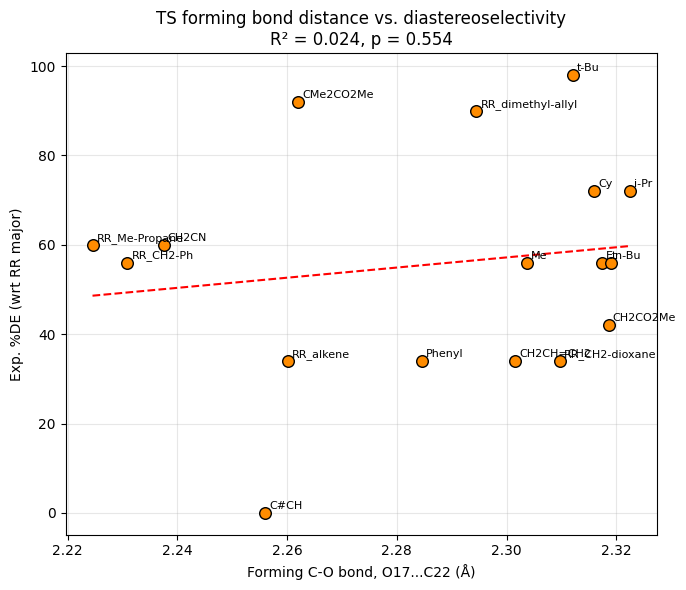

In [17]:
# ============================================================
# MERGE FORMING-BOND DISTANCE INTO MAIN DESCRIPTOR TABLE
# ============================================================
# df, df_rr_bond, df_rs_bond, out_dir, xyz_folder, exp_de, de_col
# are assumed already defined from earlier steps

# Combine RR + RS bond-distance tables into one lookup
df_bond_all = pd.concat([df_rr_bond, df_rs_bond], ignore_index=True)
df_bond_all = df_bond_all.rename(columns={"O17_C22_dist (Å)": "TS_forming_bond (Å)"})

# Merge onto the main descriptor table (from R3_Sterimol_Vbur_results_new.xlsx)
df = df.merge(df_bond_all, on="File", how="left")

missing = df[df["TS_forming_bond (Å)"].isna()]
if len(missing) > 0:
    print("⚠️ Files with no matching forming-bond distance:")
    print(missing[["File"]])
else:
    print("✅ Forming-bond distance merged for all files.")

print(df[["File", "TS_forming_bond (Å)"]])

# ============================================================
# RE-RUN CORRELATION ANALYSIS INCLUDING THE NEW DESCRIPTOR
# ============================================================
df_rr = df[df[de_col].notna()].copy()

descriptor_cols = [c for c in df.columns if c not in
                    ["File", "R3", "C2 atom", "R3 first atom", "R3 atoms", de_col]
                    and pd.api.types.is_numeric_dtype(df[c])]
print(f"\nDescriptors used: {descriptor_cols}")

results = []
for desc in descriptor_cols:
    x = df_rr[desc].values
    y = df_rr[de_col].values
    if np.std(x) == 0:
        continue
    r, p = stats.pearsonr(x, y)
    results.append({"Descriptor": desc, "Pearson r": r, "R2": r**2, "p-value": p})

corr_summary = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\nCorrelation with Exp. %DE (now including TS forming-bond distance):")
print(corr_summary.to_string(index=False))

# ============================================================
# PLOT: TS forming bond vs %DE specifically
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
x = df_rr["TS_forming_bond (Å)"].values
y = df_rr[de_col].values
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.scatter(x, y, color="darkorange", s=70, edgecolor="black", zorder=3)
ax.plot(x_line, y_line, color="red", linestyle="--", zorder=2)

label_col = "R3" if "R3" in df_rr.columns else "File"
for xi, yi, label in zip(x, y, df_rr[label_col]):
    ax.annotate(str(label), (xi, yi), fontsize=8, xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("Forming C-O bond, O17...C22 (Å)")
ax.set_ylabel("Exp. %DE (wrt RR major)")
ax.set_title(f"TS forming bond distance vs. diastereoselectivity\nR² = {r**2:.3f}, p = {p:.3g}")
ax.grid(alpha=0.3)
plt.tight_layout()

out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
plt.savefig(os.path.join(out_dir, "TS_bond_vs_DE.png"), dpi=200)
plt.show()

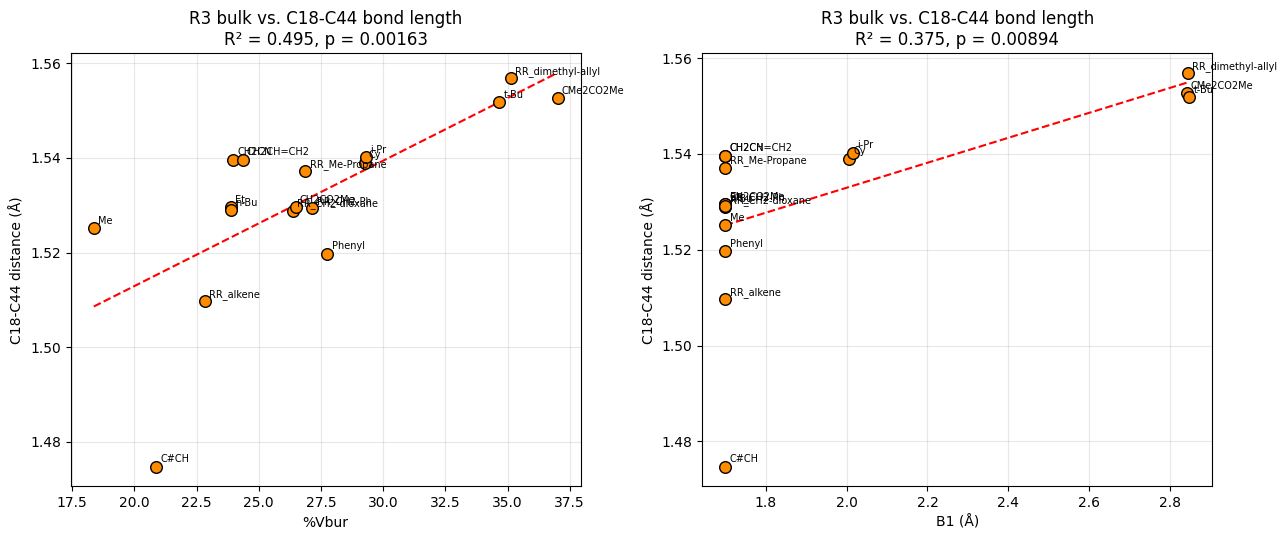

In [26]:
# ============================================================
# TEST: DOES R3 BULK (%Vbur, B1) PREDICT C18-C44 BOND ELONGATION?
# ============================================================
import matplotlib.pyplot as plt
from scipy import stats

bond_col = "C18-C44 distance (Å)"   # adjust to your exact column name if different
bulk_descriptors = ["%Vbur", "B1 (Å)"]  # adjust to your exact column names

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, desc in zip(axes, bulk_descriptors):
    x = df_rr[desc].values
    y = df_rr[bond_col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    ax.scatter(x, y, color="darkorange", s=70, edgecolor="black", zorder=3)
    ax.plot(x_line, y_line, color="red", linestyle="--", zorder=2)

    label_col = "R3" if "R3" in df_rr.columns else "File"
    for xi, yi, label in zip(x, y, df_rr[label_col]):
        ax.annotate(str(label), (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel(desc)
    ax.set_ylabel(bond_col)
    ax.set_title(f"R3 bulk vs. C18-C44 bond length\nR² = {r**2:.3f}, p = {p:.3g}")
    ax.grid(alpha=0.3)

plt.tight_layout()
out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
plt.savefig(os.path.join(out_dir, "bulk_vs_C18C44_bond.png"), dpi=200)
plt.show()

R² (bond distance alone):  0.765
R² (%Vbur alone):          0.571

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     28.69
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           1.12e-05
Time:                        11:39:57   Log-Likelihood:                -64.504
No. Observations:                  17   AIC:                             135.0
Df Residuals:                      14   BIC:                             137.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

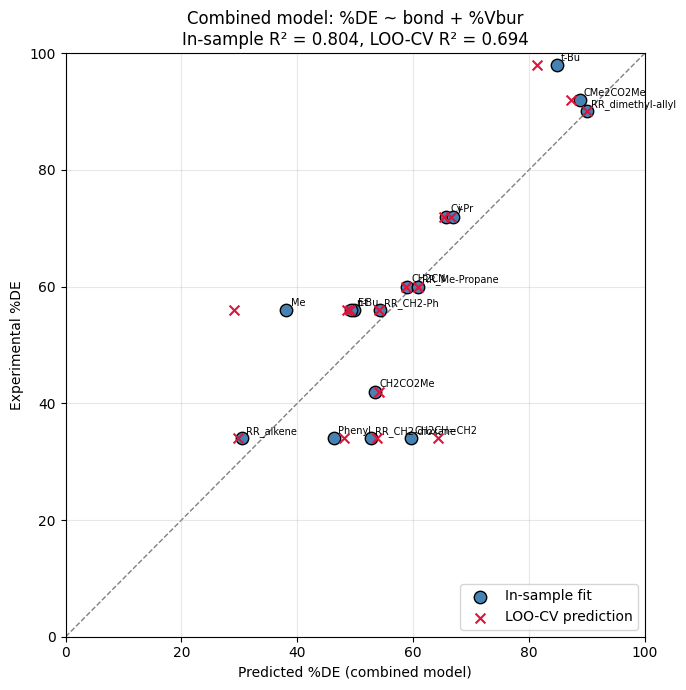


✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/multivariate_model_parity.png


In [27]:
# ============================================================
# MULTIVARIATE REGRESSION: %DE ~ %Vbur + C18-C44 bond distance
# ============================================================
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

bond_col = "C18-C44 distance (Å)"   # adjust to your exact column name if different
bulk_col = "%Vbur"                   # adjust to your exact column name if different
de_col = "Exp diastereo Selectivity (%) wrt RR (major)"

# ------------------------------------------------------------
# 1. Single-descriptor baselines (for comparison)
# ------------------------------------------------------------
def r2_single(x_col):
    x = df_rr[x_col].values
    y = df_rr[de_col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    return r**2

r2_bond_only = r2_single(bond_col)
r2_vbur_only = r2_single(bulk_col)

print(f"R² (bond distance alone):  {r2_bond_only:.3f}")
print(f"R² (%Vbur alone):          {r2_vbur_only:.3f}")

# ------------------------------------------------------------
# 2. Multivariate OLS: %DE ~ bond + %Vbur
# ------------------------------------------------------------
X = df_rr[[bond_col, bulk_col]].copy()
X = sm.add_constant(X)
y = df_rr[de_col].values

model = sm.OLS(y, X).fit()
print("\n" + "="*60)
print(model.summary())

r2_combined = model.rsquared
r2_adj = model.rsquared_adj

print(f"\nCombined model R²:          {r2_combined:.3f}")
print(f"Combined model adjusted R²: {r2_adj:.3f}")
print(f"Improvement over bond alone: {r2_combined - r2_bond_only:+.3f}")
print(f"Improvement over %Vbur alone: {r2_combined - r2_vbur_only:+.3f}")

# ------------------------------------------------------------
# 3. Check for multicollinearity (VIF) — important with only 17 points
# ------------------------------------------------------------
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factors (VIF > 5-10 indicates problematic collinearity):")
print(vif_data.to_string(index=False))

# ------------------------------------------------------------
# 4. Leave-one-out cross-validation (critical given n=17)
# ------------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

def loo_r2(X_arr, y_arr):
    loo = LeaveOneOut()
    preds = np.zeros_like(y_arr, dtype=float)
    for train_idx, test_idx in loo.split(X_arr):
        lr = LinearRegression().fit(X_arr[train_idx], y_arr[train_idx])
        preds[test_idx] = lr.predict(X_arr[test_idx])
    return r2_score(y_arr, preds), preds

X_combined = df_rr[[bond_col, bulk_col]].values
X_bond_only = df_rr[[bond_col]].values
X_vbur_only = df_rr[[bulk_col]].values

loo_r2_combined, preds_combined = loo_r2(X_combined, y)
loo_r2_bond, _ = loo_r2(X_bond_only, y)
loo_r2_vbur, _ = loo_r2(X_vbur_only, y)

print(f"\nLeave-one-out cross-validated R²:")
print(f"  Bond distance alone:  {loo_r2_bond:.3f}")
print(f"  %Vbur alone:          {loo_r2_vbur:.3f}")
print(f"  Combined model:       {loo_r2_combined:.3f}")

# ------------------------------------------------------------
# 5. Parity plot: combined model prediction vs experimental %DE
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))
fitted = model.fittedvalues

ax.scatter(fitted, y, color="steelblue", s=80, edgecolor="black", zorder=3, label="In-sample fit")
ax.scatter(preds_combined, y, color="crimson", s=50, marker="x", zorder=4, label="LOO-CV prediction")

label_col = "R3" if "R3" in df_rr.columns else "File"
for xi, yi, label in zip(fitted, y, df_rr[label_col]):
    ax.annotate(str(label), (xi, yi), fontsize=7, xytext=(3, 3), textcoords="offset points")

lims = [0, 100]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, zorder=1)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel("Predicted %DE (combined model)")
ax.set_ylabel("Experimental %DE")
ax.set_title(f"Combined model: %DE ~ bond + %Vbur\n"
             f"In-sample R² = {r2_combined:.3f}, LOO-CV R² = {loo_r2_combined:.3f}")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()

out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
plt.savefig(os.path.join(out_dir, "multivariate_model_parity.png"), dpi=200)
plt.show()
print(f"\n✅ Saved: {os.path.join(out_dir, 'multivariate_model_parity.png')}")

In [30]:
# ============================================================
# PREDICT %DE FOR NEW/UNTESTED R3 GROUPS (fast %Vbur proxy, no DFT needed)
# ============================================================
# !pip install morfeus-ml rdkit -q
!pip install rdkit morfeus-ml -q

from rdkit import Chem
from rdkit.Chem import AllChem
from morfeus import BuriedVolume, read_xyz
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. FIT THE TWO SUPPORTING REGRESSIONS FROM YOUR EXISTING DATA
# ------------------------------------------------------------
# (a) bond ~ %Vbur   (R² = 0.495, from earlier)
from scipy import stats
slope_b, intercept_b, r_b, p_b, se_b = stats.linregress(df_rr["%Vbur"], df_rr[bond_col])
print(f"bond = {slope_b:.5f} * %Vbur + {intercept_b:.4f}   (R²={r_b**2:.3f})")

# (b) %DE ~ bond + %Vbur   (combined model, already fit as `model` from before)
# reuse `model` (statsmodels OLS) from the multivariate regression cell

# ------------------------------------------------------------
# 2. DEFINE CANDIDATE R3 GROUPS TO SCREEN (edit this list freely)
# ------------------------------------------------------------
# SMILES fragments for the R3 substituent, capped with a dummy methyl
# to represent attachment at C18 (i.e., "R3-CH3" as a simple proxy molecule
# whose R3-bearing carbon mimics the real attachment geometry).
candidates = {
    "neopentyl (CH2CMe3)":      "CC(C)(C)C",
    "1-adamantyl":               "C1C2CC3CC1CC(C2)C3",
    "CEt3 (triethylmethyl)":     "CC(CC)(CC)CC",
    "SiMe3 (TMS-CH2)":           "C[Si](C)(C)C",
    "2,6-dimethylphenyl":        "Cc1cccc(C)c1",
    "CPh3 (trityl-CH2)":         "C(c1ccccc1)(c1ccccc1)c1ccccc1",
    "CMe2CF3":                   "CC(C)(C)C(F)(F)F",
    "1-methylcyclohexyl":        "CC1(C)CCCCC1",
}

# ============================================================
# 3. COMPUTE %Vbur FOR EACH CANDIDATE (fast, no DFT — RDKit embed + morfeus)
# ============================================================
def compute_vbur_from_smiles(smiles, radius=3.5):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)

    conf = mol.GetConformer()
    coords = np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]

    center_idx = 1   # morfeus expects 1-indexed atom numbering (first heavy atom in SMILES)
    bv = BuriedVolume(symbols, coords, center_idx, radius=radius)
    return bv.fraction_buried_volume * 100  # as %


results = []
for name, smi in candidates.items():
    try:
        vbur = compute_vbur_from_smiles(smi)
        bond_pred = slope_b * vbur + intercept_b

        X_new = pd.DataFrame({bond_col: [bond_pred], "%Vbur": [vbur]})
        X_new = sm.add_constant(X_new, has_constant="add")
        de_pred = model.predict(X_new)[0]
        de_pred = np.clip(de_pred, 0, 100)  # physical bound

        results.append({
            "R3 candidate": name,
            "Predicted %Vbur": round(vbur, 1),
            "Predicted bond (Å)": round(bond_pred, 4),
            "Predicted %DE": round(de_pred, 1),
        })
    except Exception as e:
        print(f"⚠️ Failed for {name}: {e}")

df_candidates = pd.DataFrame(results)
if len(df_candidates) == 0:
    print("⚠️ No candidates succeeded — check the error messages above.")
else:
    df_candidates = df_candidates.sort_values("Predicted %DE", ascending=False)
    vbur_min, vbur_max = df_rr["%Vbur"].min(), df_rr["%Vbur"].max()
    df_candidates["In training range?"] = df_candidates["Predicted %Vbur"].between(vbur_min, vbur_max)
    print(f"\nTraining %Vbur range: {vbur_min:.1f} - {vbur_max:.1f}%\n")
    print(df_candidates.to_string(index=False))

bond = 0.00265 * %Vbur + 1.4599   (R²=0.495)

Training %Vbur range: 18.4 - 37.0%

         R3 candidate  Predicted %Vbur  Predicted bond (Å)  Predicted %DE  In training range?
          1-adamantyl             51.4              1.5962          100.0               False
CEt3 (triethylmethyl)             43.8              1.5760          100.0               False
              CMe2CF3             39.2              1.5638          100.0               False
    CPh3 (trityl-CH2)             73.3              1.6544          100.0               False
   1-methylcyclohexyl             35.3              1.5534           87.1                True
  neopentyl (CH2CMe3)             34.9              1.5523           85.5                True
      SiMe3 (TMS-CH2)             34.6              1.5517           84.6                True
   2,6-dimethylphenyl             28.0              1.5341           59.5                True


In [18]:
# ============================================================
# MERGE FORMING-BOND DISTANCE INTO MAIN DESCRIPTOR TABLE
# ============================================================
# df, df_rr_bond, df_rs_bond, out_dir, xyz_folder, exp_de, de_col
# are assumed already defined from earlier steps

# Combine RR + RS bond-distance tables into one lookup
df_bond_all = pd.concat([df_rr_bond, df_rs_bond], ignore_index=True)
df_bond_all = df_bond_all.rename(columns={"O17_C22_dist (Å)": "TS_forming_bond (Å)"})

# Merge onto the main descriptor table (from R3_Sterimol_Vbur_results_new.xlsx)
df = df.merge(df_bond_all, on="File", how="left")

missing = df[df["TS_forming_bond (Å)"].isna()]
if len(missing) > 0:
    print("⚠️ Files with no matching forming-bond distance:")
    print(missing[["File"]])
else:
    print("✅ Forming-bond distance merged for all files.")

print(df[["File", "TS_forming_bond (Å)"]])

# ============================================================
# RE-RUN CORRELATION ANALYSIS INCLUDING THE NEW DESCRIPTOR
# ============================================================
df_rr = df[df[de_col].notna()].copy()

descriptor_cols = [c for c in df.columns if c not in
                    ["File", "R3", "C2 atom", "R3 first atom", "R3 atoms", de_col]
                    and pd.api.types.is_numeric_dtype(df[c])]
print(f"\nDescriptors used: {descriptor_cols}")

results = []
for desc in descriptor_cols:
    x = df_rr[desc].values
    y = df_rr[de_col].values
    if np.std(x) == 0:
        continue
    r, p = stats.pearsonr(x, y)
    results.append({"Descriptor": desc, "Pearson r": r, "R2": r**2, "p-value": p})

corr_summary = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\nCorrelation with Exp. %DE (now including TS forming-bond distance):")
print(corr_summary.to_string(index=False))

# ============================================================
# PLOT: TS forming bond vs %DE specifically
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
x = df_rr["TS_forming_bond (Å)"].values
y = df_rr[de_col].values
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

ax.scatter(x, y, color="darkorange", s=70, edgecolor="black", zorder=3)
ax.plot(x_line, y_line, color="red", linestyle="--", zorder=2)

label_col = "R3" if "R3" in df_rr.columns else "File"
for xi, yi, label in zip(x, y, df_rr[label_col]):
    ax.annotate(str(label), (xi, yi), fontsize=8, xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("Forming C-O bond, O17...C22 (Å)")
ax.set_ylabel("Exp. %DE (wrt RR major)")
ax.set_title(f"TS forming bond distance vs. diastereoselectivity\nR² = {r**2:.3f}, p = {p:.3g}")
ax.grid(alpha=0.3)
plt.tight_layout()

out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
plt.savefig(os.path.join(out_dir, "TS_bond_vs_DE.png"), dpi=200)
plt.show()

KeyError: 'TS_forming_bond (Å)'

2RT = 1.1850 kcal/mol at T = 298.15 K
               R3  ddG_DFT  Predicted_de  Exp_de  DFT_predicts_RR_major                      Sign_flag
               Me     -0.8     58.833948      56                  False                               
               Et      0.5     39.857334      56                   True                               
              iPr      0.1      8.419057      72                   True low-confidence (<0.5 kcal/mol)
             n-Bu     -0.9     64.079003      56                  False                               
             t-Bu      1.7     89.261268      98                   True                               
   CH2-CH(Me)-CH3      0.0      0.000000      60                  False low-confidence (<0.5 kcal/mol)
               Cy     -0.9     64.079003      72                  False                               
         CH2CO2Me     -0.9     64.079003      42                  False                               
        CMe2CO2Me      0.8     58.8

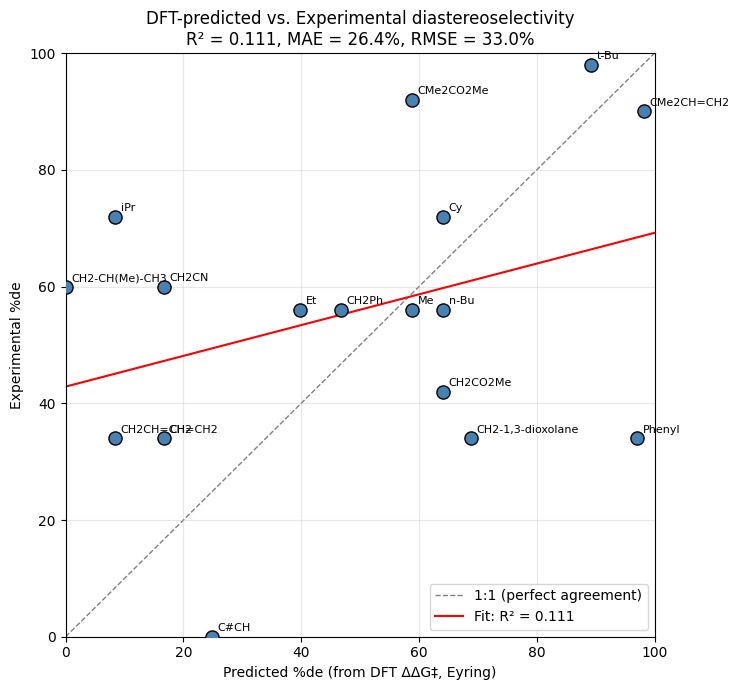


✅ Saved: /content/drive/MyDrive/xyz_files/superimposed_by_stereo/DFT_predicted_vs_exp_de.png

Largest prediction errors (check these substrates first):
               R3  ddG_DFT  Predicted_de  Exp_de  abs_error
              iPr      0.1      8.419057      72  63.580943
           Phenyl      2.5     97.101475      34  63.101475
   CH2-CH(Me)-CH3      0.0      0.000000      60  60.000000
            CH2CN      0.2     16.719605      60  43.280395
CH2-1,3-dioxolane     -1.0     68.787101      34  34.787101
        CMe2CO2Me      0.8     58.833948      92  33.166052


In [19]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# ============================================================
# 1. DATA — DFT ΔΔG‡ (kcal/mol, wrt RR) and Exp %de
# ============================================================
data = {
    "R3": ["Me", "Et", "iPr", "n-Bu", "t-Bu", "CH2-CH(Me)-CH3", "Cy", "CH2CO2Me",
           "CMe2CO2Me", "CH2CH=CH2", "CMe2CH=CH2", "CH2-1,3-dioxolane", "CH2Ph",
           "CH2CN", "Phenyl", "CH=CH2", "C#CH"],
    "ddG_DFT": [-0.8, 0.5, 0.1, -0.9, 1.7, 0.0, -0.9, -0.9, 0.8, 0.1, 2.8, -1.0,
                0.6, 0.2, 2.5, -0.2, -0.3],
    "Exp_de": [56, 56, 72, 56, 98, 60, 72, 42, 92, 34, 90, 34, 56, 60, 34, 34, 0],
}
df = pd.DataFrame(data)

# ============================================================
# 2. CONVERT ΔΔG‡ -> PREDICTED %de (Eyring/Boltzmann, at rt = 298.15 K)
# ============================================================
R_kcal = 0.0019872041   # kcal/(mol K)
T = 298.15               # K (rt, matching your reaction conditions)
RT2 = 2 * R_kcal * T
print(f"2RT = {RT2:.4f} kcal/mol at T = {T} K")

df["Predicted_de"] = np.tanh(np.abs(df["ddG_DFT"]) / RT2) * 100

# sign check: does DFT correctly predict RR as major (positive ddG)?
df["DFT_predicts_RR_major"] = df["ddG_DFT"] > 0
df["Sign_flag"] = np.where(df["ddG_DFT"].abs() < 0.5, "low-confidence (<0.5 kcal/mol)", "")

print(df[["R3", "ddG_DFT", "Predicted_de", "Exp_de", "DFT_predicts_RR_major", "Sign_flag"]]
      .to_string(index=False))

# ============================================================
# 3. CORRELATION: Predicted vs Experimental %de
# ============================================================
x = df["Predicted_de"].values
y = df["Exp_de"].values
slope, intercept, r, p, se = stats.linregress(x, y)
mae = np.mean(np.abs(x - y))
rmse = np.sqrt(np.mean((x - y) ** 2))

print(f"\nPredicted vs Experimental %de:")
print(f"  R² = {r**2:.3f}, p = {p:.3g}")
print(f"  MAE = {mae:.1f} %de, RMSE = {rmse:.1f} %de")

# ============================================================
# 4. PLOT: Predicted vs Experimental %de (parity plot)
# ============================================================
out_dir = "/content/drive/MyDrive/xyz_files/superimposed_by_stereo"
os.makedirs(out_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(7.5, 7))

ax.scatter(x, y, s=90, color="steelblue", edgecolor="black", zorder=3)
for xi, yi, label in zip(x, y, df["R3"]):
    ax.annotate(label, (xi, yi), fontsize=8, xytext=(4, 4), textcoords="offset points")

# 1:1 parity line
lims = [0, 100]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="1:1 (perfect agreement)", zorder=1)

# best-fit line
x_line = np.linspace(0, 100, 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="red", linestyle="-", linewidth=1.5,
         label=f"Fit: R² = {r**2:.3f}", zorder=2)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel("Predicted %de (from DFT ΔΔG‡, Eyring)")
ax.set_ylabel("Experimental %de")
ax.set_title(f"DFT-predicted vs. Experimental diastereoselectivity\n"
             f"R² = {r**2:.3f}, MAE = {mae:.1f}%, RMSE = {rmse:.1f}%")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(out_dir, "DFT_predicted_vs_exp_de.png")
plt.savefig(plot_path, dpi=200)
plt.show()
print(f"\n✅ Saved: {plot_path}")

# ============================================================
# 5. FLAG STRUCTURES WHERE MODEL DISAGREES MOST WITH EXPERIMENT
# ============================================================
df["abs_error"] = np.abs(df["Predicted_de"] - df["Exp_de"])
print("\nLargest prediction errors (check these substrates first):")
print(df.sort_values("abs_error", ascending=False)[["R3", "ddG_DFT", "Predicted_de", "Exp_de", "abs_error"]]
      .head(6).to_string(index=False))

In [20]:
# ============================================================
# CONE ANGLE FROM C18 VERTEX, OVER R3 ATOMS (44+)
# ============================================================
import numpy as np
import glob, os
import pandas as pd

def read_xyz(path):
    with open(path) as f:
        lines = f.readlines()
    n_atoms = int(lines[0].strip())
    symbols, coords = [], []
    for line in lines[2:2 + n_atoms]:
        parts = line.split()
        symbols.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    return symbols, np.array(coords)

# van der Waals radii (Å) — extend as needed for your R3 atoms
VDW_RADII = {
    "H": 1.10, "C": 1.70, "N": 1.55, "O": 1.52, "F": 1.47,
    "Cl": 1.75, "Br": 1.85, "S": 1.80,
}

def cone_angle_from_vertex(symbols, coords, vertex_idx_1based, substituent_idx_1based_list):
    """
    Compute the cone half-angle (and full cone angle) subtended at `vertex`
    by all atoms in `substituent_idx_1based_list`, accounting for vdW radius
    (Tolman-style: half-angle to the tangent line touching each atom's vdW sphere).
    """
    vertex = coords[vertex_idx_1based - 1]
    sub_idx = [i - 1 for i in substituent_idx_1based_list]

    # define the cone axis as vertex -> centroid of substituent atoms
    centroid = coords[sub_idx].mean(axis=0)
    axis = centroid - vertex
    axis /= np.linalg.norm(axis)

    max_half_angle = 0.0
    for i in sub_idx:
        vec = coords[i] - vertex
        dist = np.linalg.norm(vec)
        if dist < 1e-6:
            continue
        # angle between axis and vector to this atom (atom-center half-angle)
        cos_theta = np.dot(vec, axis) / dist
        cos_theta = np.clip(cos_theta, -1, 1)
        theta_center = np.degrees(np.arccos(cos_theta))

        # add angular contribution of the atom's own vdW radius (tangent-line correction)
        r_vdw = VDW_RADII.get(symbols[i], 1.70)  # default to carbon radius if unknown
        if dist > r_vdw:
            theta_vdw = np.degrees(np.arcsin(r_vdw / dist))
        else:
            theta_vdw = 90.0  # atom overlaps vertex distance-wise; cap conservatively

        theta_edge = theta_center + theta_vdw
        max_half_angle = max(max_half_angle, theta_edge)

    return 2 * max_half_angle  # full cone angle


# ============================================================
# RUN ON ALL FILES — R3 = atoms 44 to end (adjust if some files differ)
# ============================================================
xyz_folder = "/content/drive/MyDrive/xyz_files"

def analyze_cone_angle(prefix):
    files = sorted(glob.glob(os.path.join(xyz_folder, f"{prefix}_*.xyz")))
    rows = []
    for f in files:
        symbols, coords = read_xyz(f)
        n_atoms = len(symbols)
        r3_atoms = list(range(44, n_atoms + 1))  # 1-indexed, from 44 to last atom
        if len(r3_atoms) == 0:
            print(f"⚠️ {os.path.basename(f)}: no R3 atoms found (n_atoms={n_atoms})")
            continue
        angle = cone_angle_from_vertex(symbols, coords, vertex_idx_1based=18,
                                        substituent_idx_1based_list=r3_atoms)
        rows.append({"File": os.path.basename(f), "Cone_angle_C18 (deg)": angle,
                     "n_R3_atoms": len(r3_atoms)})
    return pd.DataFrame(rows)

df_rr_cone = analyze_cone_angle("RR")
print(df_rr_cone.to_string(index=False))

out_dir = os.path.join(xyz_folder, "superimposed_by_stereo")
os.makedirs(out_dir, exist_ok=True)
df_rr_cone.to_csv(os.path.join(out_dir, "RR_cone_angle.csv"), index=False)

                 File  Cone_angle_C18 (deg)  n_R3_atoms
        RR_CH2-Ph.xyz            255.097538          14
   RR_CH2-dioxane.xyz            251.483992          13
         RR_CH2CN.xyz            211.189459           5
      RR_CH2CO2Me.xyz            247.016773          10
     RR_CMe2CO2Me.xyz            217.139019          16
            RR_Cy.xyz            208.275548          17
            RR_Et.xyz            224.067739           7
    RR_Me-Propane.xyz            235.665808          13
            RR_Me.xyz            180.369120           4
            RR_Ph.xyz            181.464024          11
        RR_alkene.xyz            213.460882           5
        RR_alkyne.xyz            180.405968           3
         RR_allyl.xyz            230.559276           8
RR_dimethyl-allyl.xyz            192.640661          14
           RR_iPr.xyz            209.502912          10
           RR_nBu.xyz            234.035320          13
           RR_tBu.xyz            181.860583     